### FIRST DRAFT FOR CODE

### PROJECT: LINEAR REGRESSION FROM SCRATCH WITH NUMPY
Goal: To implement, train, and validate a linear regression model from scratch to predict Boston house prices.

### 1. Import all necessary libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split # train_test_split function from sickit-learn library
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression as SklearnLinearRegression
from sklearn.metrics import mean_squared_error

### 2. Data Loading

In [ ]:
url = 'https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv'
boston_df = pd.read_csv(url) # load data
boston_df.head(10) # displays first 10 rows of the boston housing dataset

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,386.71,17.10,18.9


### 3. Data Preprocessing
3.1. Feature-Target Split and Train-Test Split

In [ ]:
y = boston_df['medv'] # target vector y, medv is median value of owner-occupied homes
X = boston_df.drop('medv', axis = 1) # feature (inputs) matrix, contains all columns except medv

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

3.2. Feature Scaling

In [ ]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train = scaler.fit_transform(X_train)

# Use the SAME scaler to transform the test data
X_test = scaler.transform(X_test)

### 4. Linear Regression Model Implementation from scratch
This class implements the linear regression model from scratch. The hypothesis is defined by the equation:
$$ h_{\theta}(x) = \theta^T x $$
The model is optimised using Gradient Descent to minimise the Mean Squared Error (MSE) cost function, $J(\theta)$:
$$ J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (h_{\theta}(x^{(i)}) - y^{(i)})^2 $$

In [ ]:
class LinearRegression:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.theta = None
        self.cost_history = []

    def fit(self, X, y):
        """Trains the model using gradient descent."""
        # 1. Initialize parameters
        n_samples, n_features = X.shape
        self.theta = np.zeros(n_features)

        # 2. Gradient Descent loop
        for _ in range(self.n_iterations):
            # Calculate hypothesis
            hyp = X @ self.theta

            # Calculate cost and store it
            cost = (1 / (2 * n_samples)) * np.sum((hyp - y)**2)
            self.cost_history.append(cost)

            # Calculate the gradient
            gradient = (1 / n_samples) * (X.T @ (hyp - y))

            # Update theta
            self.theta -= self.learning_rate * gradient

    def predict(self, X):
        """Makes predictions using the learned theta."""
        # This also assumes X will have a bias column of ones when passed in
        return X @ self.theta

### 5. Preparing Data and Model Training

In [ ]:
# Add the bias term to your data (CRUCIAL STEP)
X_train_b = np.c_[np.ones(X_train.shape[0]), X_train]
X_test_b = np.c_[np.ones(X_test.shape[0]), X_test]

# Initialize and train the model
model = LinearRegression(learning_rate=0.01, n_iterations=2000)
model.fit(X_train_b, y_train)

## 6. Results and Evaluation
6.1. Visualising the Cost Function

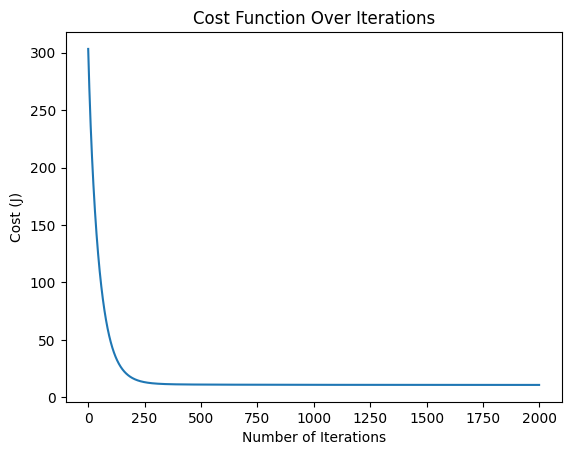

In [ ]:
# Plot the cost history
plt.plot(model.cost_history)
plt.title("Cost Function Over Iterations")
plt.xlabel("Number of Iterations")
plt.ylabel("Cost (J)")
plt.show()

6.2. Model Evaluation and Validation against Scikit-Learn

In [ ]:
# 3. Make predictions on the test set
hyp = model.predict(X_test_b)

# 4. Evaluate the model
def mse(y_true, y_predicted):
    return np.mean((y_true - y_predicted)**2)

test_mse = mse(y_test, hyp)
print(f"The final MSE on the test set is: {test_mse}")

# Train Scikit-learn's model
sklearn_model = SklearnLinearRegression()
sklearn_model.fit(X_train, y_train)

# Compare MSE on the test set
your_mse = mse(y_test, hyp)
sklearn_mse = mean_squared_error(y_test, sklearn_model.predict(X_test))

print(f"Scikit-learn's MSE: {sklearn_mse}")

The final MSE on the test set is: 24.691478766876305
Scikit-learn's MSE: 24.291119474973513


### 7. Conclusion
The from-scratch implementation of Linear Regression performed successfully, achieving an MSE of 24.69, which is nearly identical to the Scikit-learn library's result of 24.29. This validates the correctness of the custom implementation.